In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.nn.functional import softmax
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, roc_curve
import random
import matplotlib.pyplot as plt
import shap
from collections import defaultdict

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [2]:
MODEL = "NaturalAntibody/nanoBERT"
train_csv = "data/CD-HIT/90/EGFR/train_data.csv"
val_csv = "data/CD-HIT/90/EGFR/val_data.csv"
seq_col = "Sequence"
label_col = "Label"
cluster_col = "Cluster_name"
max_len = 160
num_labels = 2
epochs = 10
learning_rate = 2e-5
batch_size = 32
space_separated = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tok = AutoTokenizer.from_pretrained(MODEL, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=num_labels).to(device)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at NaturalAntibody/nanoBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
opt = AdamW(model.parameters(), lr=learning_rate)

In [4]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)

train_seqs = train_df[seq_col].astype(str).tolist()
train_labels = train_df[label_col].astype(int).tolist()
val_seqs = val_df[seq_col].astype(str).tolist()
val_labels = val_df[label_col].astype(int).tolist()

In [5]:
class DS(Dataset):
    def __init__(self, seqs, labels, clusters = None, cluster_key ="Cluster_name"):
        self.seqs = seqs
        self.labels = labels
        self.clusters = clusters
        self.cluster_key = cluster_key

        if self.clusters is not None:
            assert len(self.seqs) == len(self.clusters), "The number of sequences and clusters must be the same."

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        s = self.seqs[idx]
        if space_separated:
            s = " ".join(list(s))
            
        x = tok(
            s,
            truncation=True,
            max_length=max_len,
            padding="max_length",
            return_tensors="pt",
        )
        x = {k: v.squeeze(0) for k, v in x.items()}
        x["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.clusters is not None:
            x[self.cluster_key] = torch.tensor(self.clusters[idx], dtype=torch.long)
        return x

In [6]:
def eval_metrics(model, dl):
    model.eval()
    all_scores = []
    all_labels = []
    with torch.no_grad():
        for b in dl:
            b = {k: v.to(device) for k, v in b.items()}
            outputs = model(input_ids=b["input_ids"], attention_mask=b["attention_mask"])
            logits = outputs.logits
            scores = torch.softmax(logits, dim=-1)[:, 1]
            all_scores.append(scores.cpu())
            all_labels.append(b["labels"].cpu())
    all_scores = torch.cat(all_scores).numpy()
    all_labels = torch.cat(all_labels).numpy()

    all_preds = (all_scores > 0.5).astype(int)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds)

    return accuracy, precision, recall, f1


In [7]:
train_dl = DataLoader(DS(train_seqs, train_labels), batch_size=batch_size, shuffle=True)
val_dl = DataLoader(DS(val_seqs, val_labels), batch_size=batch_size, shuffle=False)

In [8]:
best_prec = -1
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for b in train_dl:
        b = {k: v.to(device) for k, v in b.items()}
        opt.zero_grad()
        outputs = model(**b)
        loss = outputs.loss
        loss.backward()
        opt.step()
        total_loss += loss.item()
    train_loss = total_loss / max(1, len(train_dl))
    val_acc, val_prec, val_rec, val_f1 = eval_metrics(model, val_dl)

    if val_prec > best_prec:
        best_prec = val_prec
        model.save_pretrained("nanobert_best_precision_finetuned")
        tok.save_pretrained("nanobert_best_precision_finetuned")
        print(f"Saving model with best val precision: {best_prec:.4f}")

    print(f"Epoch {epoch+1}: train loss {train_loss:.4f},"
          f" val acc {val_acc:.4f}, val prec {val_prec:.4f}," 
          f"val rec {val_rec:.4f}, val f1 {val_f1:.4f}")

Saving model with best val precision: 0.6427
Epoch 1: train loss 0.6746, val acc 0.5940, val prec 0.6427,val rec 0.4343, val f1 0.5183


Epoch 2: train loss 0.6654, val acc 0.6027, val prec 0.5887,val rec 0.6978, val f1 0.6386


Epoch 3: train loss 0.6621, val acc 0.6013, val prec 0.6121,val rec 0.5665, val f1 0.5884


Epoch 4: train loss 0.6592, val acc 0.6049, val prec 0.6035,val rec 0.6259, val f1 0.6145


Epoch 5: train loss 0.6561, val acc 0.6086, val prec 0.6292,val rec 0.5406, val f1 0.5815


Epoch 6: train loss 0.6528, val acc 0.6025, val prec 0.6233,val rec 0.5300, val f1 0.5729


Epoch 7: train loss 0.6487, val acc 0.6014, val prec 0.6066,val rec 0.5909, val f1 0.5986


Epoch 8: train loss 0.6442, val acc 0.6087, val prec 0.6003,val rec 0.6649, val f1 0.6310


Epoch 9: train loss 0.6397, val acc 0.6095, val prec 0.5967,val rec 0.6902, val f1 0.6400


Epoch 10: train loss 0.6344, val acc 0.6093, val prec 0.6037,val rec 0.6503, val f1 0.6261


In [9]:
test_csv = "data/CD-HIT/90/EGFR/test_combined_data.csv"
test_df = pd.read_csv(test_csv)
test_seqs = test_df[seq_col].astype(str).tolist()
test_labels = test_df[label_col].astype(int).tolist()
test_cluster_ids, _ = pd.factorize(test_df[cluster_col].astype(str))
test_cluster_ids = test_cluster_ids.tolist()
test_dl = DataLoader(DS(test_seqs, test_labels, clusters=test_cluster_ids, cluster_key="Cluster_name"), batch_size=batch_size, shuffle=False)

In [10]:
def diversity_at_k (cluster_ids, scores, k=100):
    cluster_ids = np.asarray(cluster_ids)   # <-- add this
    scores = np.asarray(scores) 
    k = min(k, len(scores))
    top_idx = np.argsort(scores)[::-1][:k]
    return len(np.unique(cluster_ids[top_idx]))
    

In [11]:
def metrics_at_k(all_labels, all_scores, k):
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)

    sorted_indices = np.argsort(all_scores)[::-1]
    k_eff = min(k, len(all_labels))
    top_k_indices = sorted_indices[:k_eff]

    top_k_labels = all_labels[top_k_indices]
    
    num_pos_total = all_labels.sum()
    num_pos_top_k = top_k_labels.sum()

    precision_at_k = num_pos_top_k / max(1, k_eff)
    recall_at_k = num_pos_top_k / max(1, num_pos_total)

    prevalence = num_pos_total / len(all_labels)
    ef_at_k = precision_at_k / max(prevalence, 1e-12)

    return precision_at_k, recall_at_k, ef_at_k


In [12]:
def evaluate_test(model, test_dl, device, k=100, cluster_key=None):
    model.eval()

    all_labels = []
    all_preds = []
    all_scores = []
    all_clusters = [] if cluster_key is not None else None

    with torch.no_grad():
        for b in test_dl:

            if cluster_key is not None:
                if cluster_key not in b:
                    raise KeyError(f"Key {cluster_key} not found in the batch.")
                cluster = b[cluster_key]
                all_clusters.extend(cluster.cpu().numpy())

            labels = b["labels"].to(device)
            b = {kk: vv.to(device) for kk, vv in b.items() if kk !=cluster_key}

            outputs = model(**b)
            logits = outputs.logits
            probs = softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_scores.extend(probs[:, 1].cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_scores)
    precision_1, recall_1, _ = precision_recall_curve(all_labels, all_scores)
    pr_auc = auc(recall_1, precision_1)

    precision_at_k, recall_at_k, ef_at_k = metrics_at_k(all_labels, all_scores, k)
    precision_at_1000, _, _ = metrics_at_k(all_labels, all_scores, 1000)

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        f"precision@{k}": precision_at_k,
        f"recall@{k}": recall_at_k,
        f"ef@{k}": ef_at_k,
        "precision@1000": precision_at_1000
    }

    if cluster_key is not None:
        div_at_k = diversity_at_k(all_clusters, all_scores, k=k)
        metrics[f"diversity@{k}"] = div_at_k

    return metrics




In [13]:
best_dir = "nanobert_best_precision_finetuned"
best_model = AutoModelForSequenceClassification.from_pretrained(best_dir).to(device)
best_tok = AutoTokenizer.from_pretrained(best_dir)
best_model.eval()
metrics = evaluate_test(best_model, test_dl, device, k=100, cluster_key="Cluster_name")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

accuracy: 0.5941
precision: 0.6394
recall: 0.4360
f1: 0.5185
roc_auc: 0.6394
pr_auc: 0.6254
precision@100: 0.7300
recall@100: 0.0052
ef@100: 1.4566
precision@1000: 0.7340
diversity@100: 93.0000


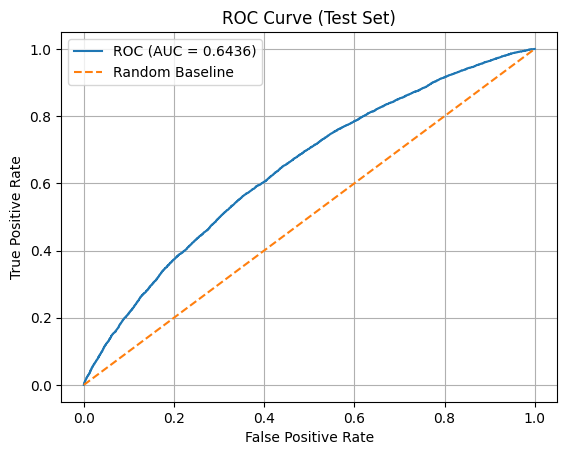

In [14]:
model.eval()
all_labels = []
all_scores = []

with torch.no_grad():
    for b in test_dl:
        labels = b["labels"].to(device)
        b = {kk: vv.to(device) for kk, vv in b.items() if kk != "Cluster_name"}  # keep this if Cluster_name exists

        outputs = model(**b)
        probs = torch.softmax(outputs.logits, dim=-1)

        all_labels.extend(labels.cpu().numpy())
        all_scores.extend(probs[:, 1].cpu().numpy())

# 2) ROC points + AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
roc_auc = auc(fpr, tpr)

# 3) Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.grid(True)
plt.show()

In [15]:

test_df["pred_score"] = all_scores
test_df["pred_label"] = (test_df["pred_score"] > 0.5).astype(int)

top100_df = test_df.sort_values("pred_score", ascending=False).head(100)

tp_top100_df = top100_df[top100_df["Label"] == 1].copy()

export_df = tp_top100_df[[
    "Cluster_name",
    "Nanobody_id",
    "Label",
    "pred_label",
    "pred_score",
    "Sequence",
    "CDR1",
    "CDR2",
    "CDR3",
    "CDR1 aligned",
    "CDR2 aligned",
    "CDR3 aligned",
    "Aligned Sequence"
]]

export_df.to_csv("nanobert_fineted_top100.csv", index=False)
print("Saved:", len(export_df), "nanobert_fineted_top100.csv")
print("Precision@100 =", len(tp_top100_df) / 100)

Saved: 80 nanobert_fineted_top100.csv
Precision@100 = 0.8


SHAP

In [16]:
save_dir = "nanobert_best_precision_finetuned"
tok = AutoTokenizer.from_pretrained(save_dir)
model = AutoModelForSequenceClassification.from_pretrained(save_dir).to(device)
model.eval()

max_len = 160
space_separated = False

In [17]:
def _fmt_seq(s: str) -> str:
    s = str(s)
    return " ".join(list(s)) if space_separated else s

def predict_proba(seqs, batch_size=32):
    """
    seqs: list[str]
    returns: np.ndarray shape (n,) with probability of class 1
    """
    seqs = [_fmt_seq(s) for s in seqs]
    out_probs = []

    for i in range(0, len(seqs), batch_size):
        batch = seqs[i:i+batch_size]
        enc = tok(
            batch,
            truncation=True,
            max_length=max_len,
            padding="max_length",
            return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits                      # (B,2)
            p1 = torch.softmax(logits, dim=-1)[:, 1]          # P(class=1)

        out_probs.append(p1.detach().cpu().numpy())

    return np.concatenate(out_probs, axis=0)

In [18]:
# probabilities for all test sequences
test_probs = predict_proba(test_seqs)

# index of highest P(class=1)
top_idx_1 = int(np.argmax(test_probs))
top_seq = test_seqs[top_idx_1]
top_p = float(test_probs[top_idx_1])

print("Top test index:", top_idx_1)
print("Top P(class=1):", top_p)
print("Sequence:", top_seq)

Top test index: 26519
Top P(class=1): 0.7489851713180542
Sequence: QVQLQESGGGLVQAGGSLRLSCAASGSISTRAMGWYRQAPGKERELVASISSGSSTNYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAADNHHARGHRYWGQGTQVTVSS


In [19]:
background = train_seqs[:400]

masker = shap.maskers.Text(tok)
explainer = shap.Explainer(predict_proba, masker, algorithm="partition")

In [20]:
sv_top = explainer([top_seq])     
shap.plots.text(sv_top[0])        

In [21]:
special = {"[CLS]", "[SEP]", "[PAD]"}

tokens = sv_top[0].data
values = sv_top[0].values

pairs = [(t, float(v)) for t, v in zip(tokens, values) if t not in special]

# top 20 by absolute contribution
top20 = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)[:20]

print("Top 20 influential tokens:")
for t, v in top20:
    print(f"{t:>8s}  {v:+.5f}")

Top 20 influential tokens:
       R  +0.03670
       R  +0.02658
       A  +0.02417
       R  +0.01304
       Y  +0.01304
       R  +0.01264
       Q  +0.01264
       S  +0.01010
       T  +0.01010
       S  +0.00951
       G  +0.00951
       G  +0.00944
       H  +0.00944
       A  +0.00934
       S  +0.00917
       S  +0.00917
       S  +0.00896
       I  +0.00896
       M  +0.00740
       G  +0.00740



PartitionExplainer explainer:   8%|▊         | 24/300 [00:00<?, ?it/s]


PartitionExplainer explainer:   9%|▊         | 26/300 [00:10<00:58,  4.70it/s]


PartitionExplainer explainer:   9%|▉         | 27/300 [00:10<01:21,  3.33it/s]


PartitionExplainer explainer:   9%|▉         | 28/300 [00:11<01:33,  2.90it/s]


PartitionExplainer explainer:  10%|▉         | 29/300 [00:11<01:40,  2.69it/s]

...


PartitionExplainer explainer:  99%|█████████▉| 298/300 [02:05<00:00,  2.35it/s]


PartitionExplainer explainer: 100%|█████████▉| 299/300 [02:06<00:00,  2.35it/s]


PartitionExplainer explainer: 100%|██████████| 300/300 [02:06<00:00,  2.35it/s]


PartitionExplainer explainer: 301it [02:07,  2.35it/s]                         


PartitionExplainer explainer: 301it [02:07,  2.18it/s]

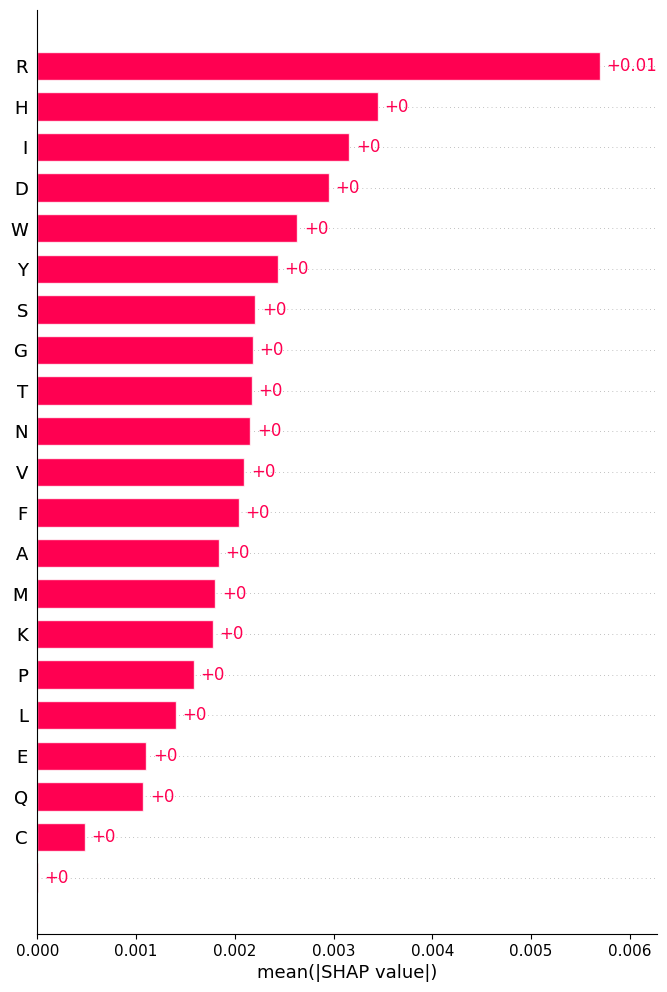

In [22]:
n_global = min(300, len(test_seqs))
sv_test = explainer(test_seqs[:n_global])

# global importance (mean |SHAP| aggregated)
shap.plots.bar(sv_test, max_display=30)

# distribution view (if it renders well)
#shap.plots.beeswarm(sv_test, max_display=30)

In [23]:
special = {"[CLS]", "[SEP]", "[PAD]"}

sum_abs = defaultdict(float)
sum_val = defaultdict(float)
count = defaultdict(int)

for i in range(len(sv_test)):
    toks = sv_test[i].data
    vals = sv_test[i].values
    for t, v in zip(toks, vals):
        if t in special:
            continue
        v = float(v)
        sum_abs[t] += abs(v)
        sum_val[t] += v
        count[t] += 1

rows = []
for t in count:
    rows.append({
        "token": t,
        "mean_abs_shap": sum_abs[t] / count[t],
        "mean_shap": sum_val[t] / count[t],
        "count": count[t],
    })

global_df = pd.DataFrame(rows).sort_values("mean_abs_shap", ascending=False)
global_df.head(30)
global_df.to_csv("nanobert_finetuned_global_shap_token_summary.csv", index=False)


PartitionExplainer explainer:  16%|█▌        | 24/150 [00:00<?, ?it/s]


PartitionExplainer explainer:  17%|█▋        | 26/150 [00:10<00:26,  4.72it/s]


PartitionExplainer explainer:  18%|█▊        | 27/150 [00:11<00:36,  3.33it/s]


PartitionExplainer explainer:  19%|█▊        | 28/150 [00:11<00:42,  2.88it/s]


PartitionExplainer explainer:  19%|█▉        | 29/150 [00:11<00:45,  2.67it/s]

...


PartitionExplainer explainer:  98%|█████████▊| 83/85 [00:35<00:00,  2.34it/s]


PartitionExplainer explainer:  99%|█████████▉| 84/85 [00:35<00:00,  2.34it/s]


PartitionExplainer explainer: 100%|██████████| 85/85 [00:35<00:00,  2.34it/s]


PartitionExplainer explainer: 86it [00:36,  2.34it/s]                        


PartitionExplainer explainer: 86it [00:36,  1.71it/s]

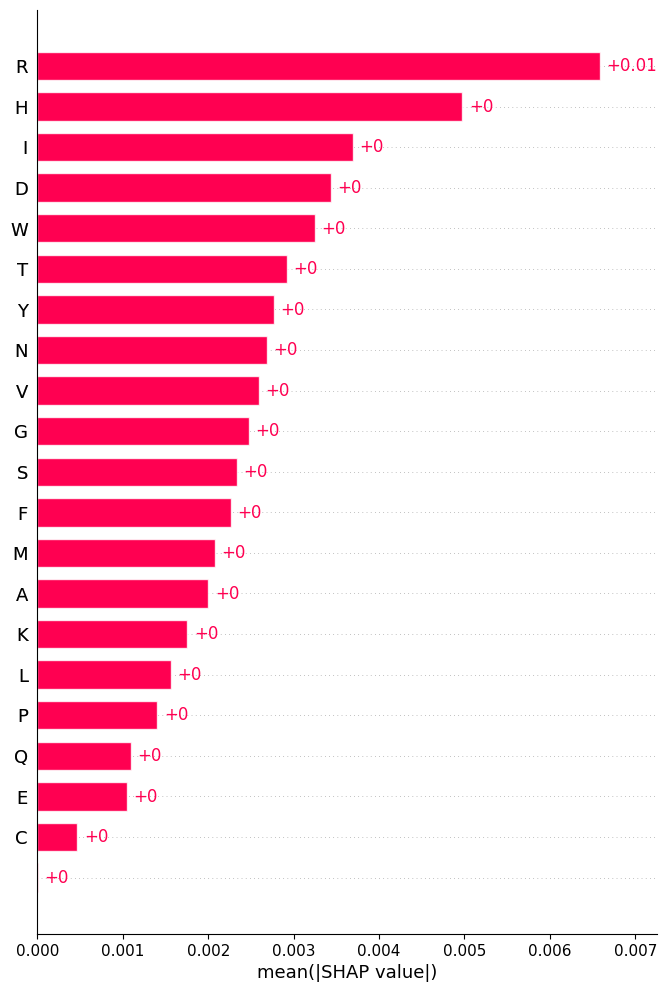

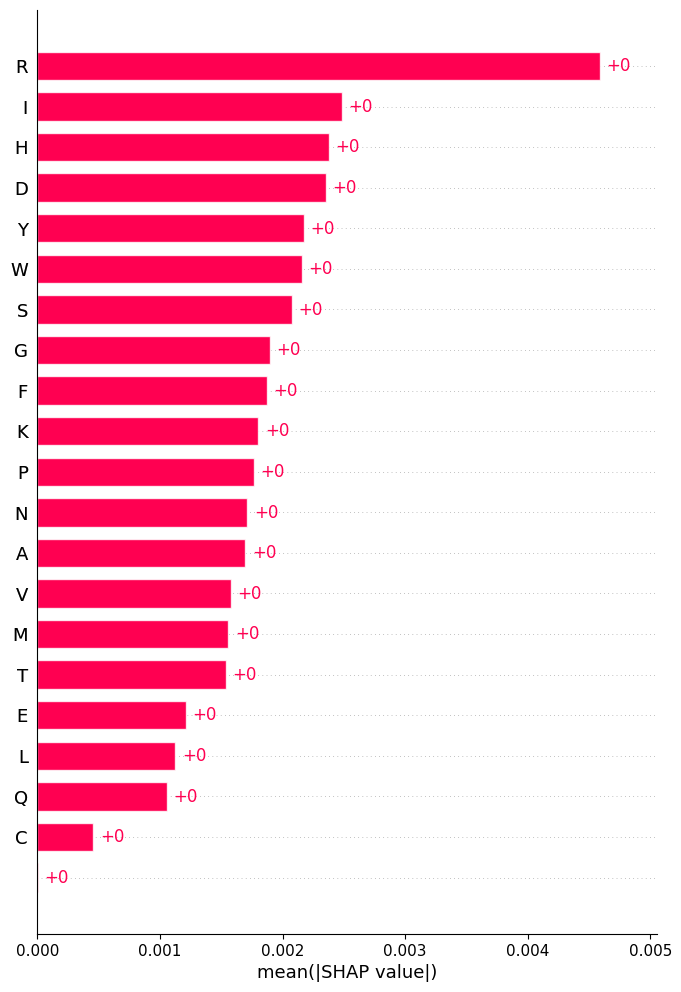

In [24]:
idx_pos = [i for i,y in enumerate(test_labels[:n_global]) if y == 1]
idx_neg = [i for i,y in enumerate(test_labels[:n_global]) if y == 0]

sv_pos = explainer([test_seqs[i] for i in idx_pos[:150]])
sv_neg = explainer([test_seqs[i] for i in idx_neg[:150]])

shap.plots.bar(sv_pos, max_display=25)
shap.plots.bar(sv_neg, max_display=25)